In [1]:
import Metrica_IO as mio
import Metrica_Viz as mviz

In [2]:
DATADIR = "data"
game_id = 2

In [3]:
events = mio.read_event_data(DATADIR, game_id)


In [4]:
# count the number of each event type in the data
print(events["Type"].value_counts())


Type
PASS              964
CHALLENGE         311
RECOVERY          248
BALL LOST         233
SET PIECE          80
BALL OUT           49
SHOT               24
FAULT RECEIVED     20
CARD                6
Name: count, dtype: int64


In [5]:
# Bit of housekeeping: unit conversion from metric data units to meters
events = mio.to_metric_coordinates(events)

# Get events by team
home_events = events[events["Team"] == "Home"]
away_events = events[events["Team"] == "Away"]

# Frequency of each event type by team
home_events["Type"].value_counts()
away_events["Type"].value_counts()

# Get all shots
shots = events[events["Type"] == "SHOT"]
home_shots = home_events[home_events.Type == "SHOT"]
away_shots = away_events[away_events.Type == "SHOT"]


In [6]:
# Look at frequency of each shot Subtype
home_shots["Subtype"].value_counts()


Subtype
ON TARGET-SAVED        4
HEAD-OFF TARGET-OUT    4
OFF TARGET-OUT         2
ON TARGET-GOAL         2
HEAD-ON TARGET-GOAL    1
Name: count, dtype: int64

In [7]:
away_shots["Subtype"].value_counts()


Subtype
OFF TARGET-OUT         3
BLOCKED                2
ON TARGET-GOAL         2
ON TARGET-SAVED        2
OFF TARGET-HEAD-OUT    1
HEAD-OFF TARGET-OUT    1
Name: count, dtype: int64

In [8]:
# Get the shots that led to a goal
home_goals = home_shots[home_shots["Subtype"].str.contains("-GOAL")].copy()
away_goals = away_shots[away_shots["Subtype"].str.contains("-GOAL")].copy()


In [9]:
# Add a column event 'Minute' to the data frame
home_goals["Minute"] = home_goals["Start Time [s]"] / 60.0


Text(-47.7, -3.400000000000003, '')

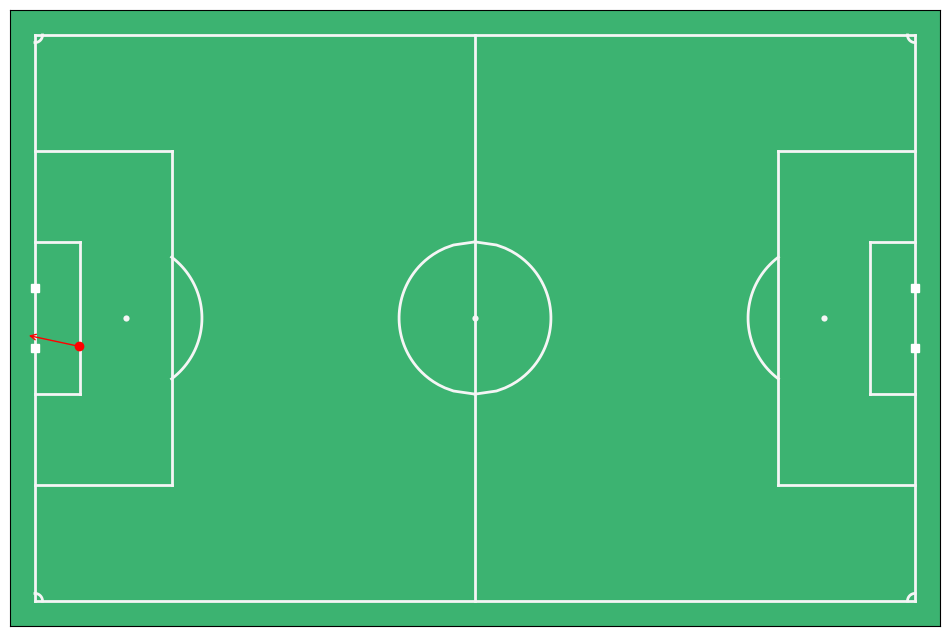

In [10]:
# Plot the first goal
fig, ax = mviz.plot_pitch()
ax.plot(events.loc[198]["Start X"], events.loc[198]["Start Y"], "ro")
ax.annotate(
    "",
    xy=events.loc[198][["End X", "End Y"]],
    xytext=events.loc[198][["Start X", "Start Y"]],
    alpha=0.6,
    arrowprops=dict(arrowstyle="->", color="r"),
)


(<Figure size 1200x800 with 1 Axes>, <Axes: >)

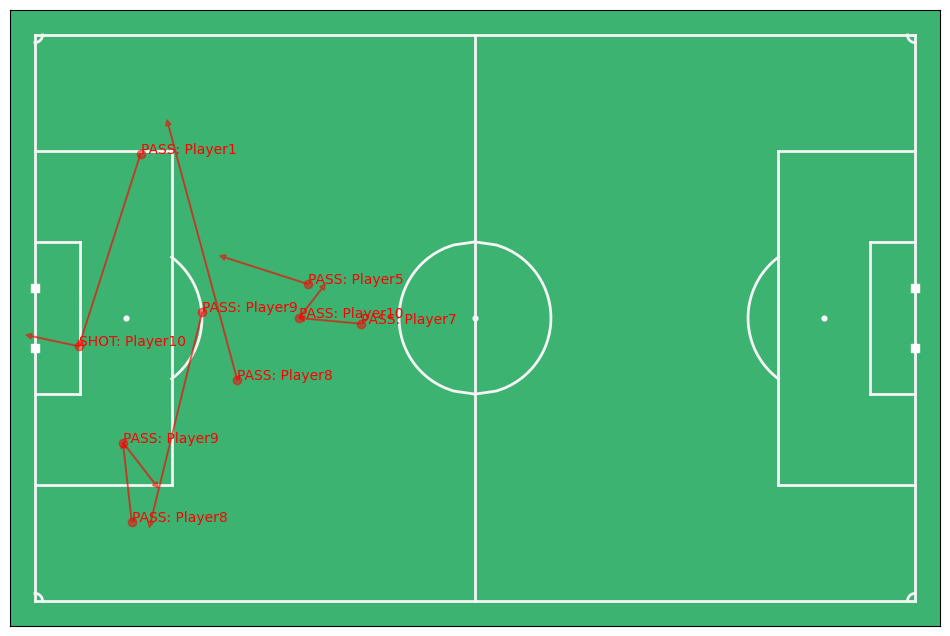

In [11]:
# plot passing move in run up to goal
mviz.plot_events(events.loc[190:198], indicators=["Marker", "Arrow"], annotate=True)


In [12]:
#### TRACKING DATA ####

# READING IN TRACKING DATA
tracking_home = mio.tracking_data(DATADIR, game_id, "Home")
tracking_away = mio.tracking_data(DATADIR, game_id, "Away")

# Look at the column namems
print(tracking_home.columns)

# Convert positions from metrica units to meters
tracking_home = mio.to_metric_coordinates(tracking_home)
tracking_away = mio.to_metric_coordinates(tracking_away)


Reading team: home
Reading team: away
Index(['Period', 'Time [s]', 'Home_11_x', 'Home_11_y', 'Home_1_x', 'Home_1_y',
       'Home_2_x', 'Home_2_y', 'Home_3_x', 'Home_3_y', 'Home_4_x', 'Home_4_y',
       'Home_5_x', 'Home_5_y', 'Home_6_x', 'Home_6_y', 'Home_7_x', 'Home_7_y',
       'Home_8_x', 'Home_8_y', 'Home_9_x', 'Home_9_y', 'Home_10_x',
       'Home_10_y', 'Home_12_x', 'Home_12_y', 'Home_13_x', 'Home_13_y',
       'Home_14_x', 'Home_14_y', 'ball_x', 'ball_y'],
      dtype='object')


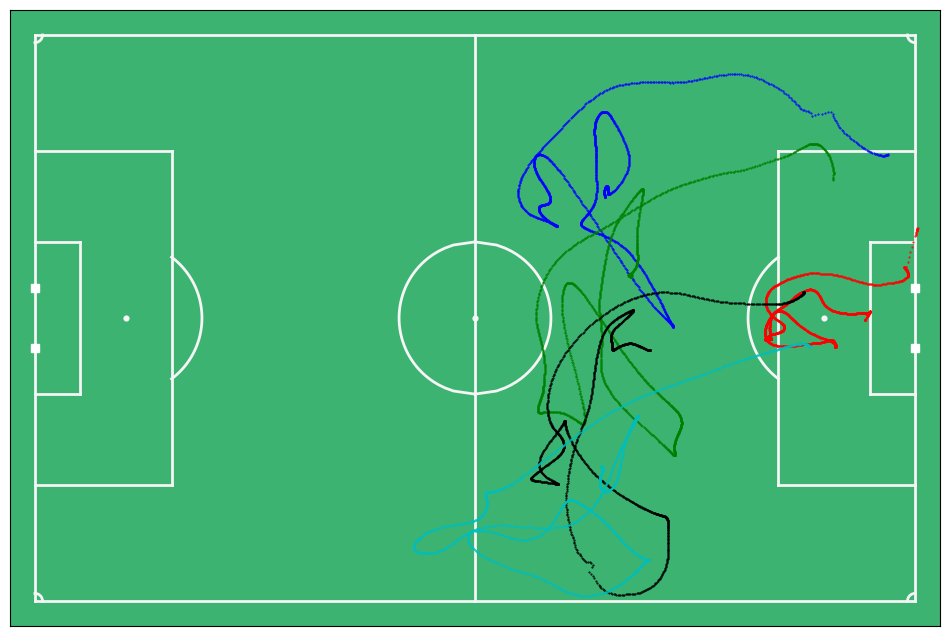

In [13]:
# Plot some player trajectories (players 11,1,2,3,4)
fig, ax = mviz.plot_pitch()
ax.plot(
    tracking_home["Home_11_x"].iloc[:1500],
    tracking_home["Home_11_y"].iloc[:1500],
    "r.",
    markersize=1,
)
ax.plot(
    tracking_home["Home_1_x"].iloc[:1500],
    tracking_home["Home_1_y"].iloc[:1500],
    "b.",
    markersize=1,
)
ax.plot(
    tracking_home["Home_2_x"].iloc[:1500],
    tracking_home["Home_2_y"].iloc[:1500],
    "g.",
    markersize=1,
)
ax.plot(
    tracking_home["Home_3_x"].iloc[:1500],
    tracking_home["Home_3_y"].iloc[:1500],
    "k.",
    markersize=1,
)
ax.plot(
    tracking_home["Home_4_x"].iloc[:1500],
    tracking_home["Home_4_y"].iloc[:1500],
    "c.",
    markersize=1,
)


# Formation Analysis

In [14]:
import pandas as pd
import numpy as np
import Metrica_Velocities as mvel

In [15]:
# Define the data directory and game ID
DATADIR = "data"
GAME_ID = 2

# Load tracking and event data
tracking_home, tracking_away, events = mio.read_match_data(DATADIR, GAME_ID)

# Convert positions from Metrica units to meters
tracking_home = mio.to_metric_coordinates(tracking_home)
tracking_away = mio.to_metric_coordinates(tracking_away)


Reading team: home
Reading team: away


In [16]:
tracking_home, tracking_away, events = mio.read_match_data(DATADIR, GAME_ID)

Reading team: home
Reading team: away


In [17]:
tracking_away.columns

Index(['Period', 'Time [s]', 'Away_25_x', 'Away_25_y', 'Away_15_x',
       'Away_15_y', 'Away_16_x', 'Away_16_y', 'Away_17_x', 'Away_17_y',
       'Away_18_x', 'Away_18_y', 'Away_19_x', 'Away_19_y', 'Away_20_x',
       'Away_20_y', 'Away_21_x', 'Away_21_y', 'Away_22_x', 'Away_22_y',
       'Away_23_x', 'Away_23_y', 'Away_24_x', 'Away_24_y', 'Away_26_x',
       'Away_26_y', 'ball_x', 'ball_y'],
      dtype='object')

In [18]:
tracking_home

,Period,Time [s],Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,...,Home_10_x,Home_10_y,Home_12_x,Home_12_y,Home_13_x,Home_13_y,Home_14_x,Home_14_y,ball_x,ball_y
Frame,,,,,,,,,,,,,,,,,,,,,
1,1,0.04,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0.08,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0.12,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0.16,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,0.20,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.50194,0.61123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2,5646.08,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,NaN,NaN,0.40837,0.14449,0.51032,0.94554,0.27962,0.36700,NaN,NaN
141153,2,5646.12,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,NaN,NaN,0.40837,0.14449,0.51031,0.94626,0.28009,0.36718,NaN,NaN
141154,2,5646.16,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,NaN,NaN,0.40837,0.14449,0.51029,0.94711,0.28031,0.36726,NaN,NaN


In [19]:
# Compute player velocities
tracking_home = mvel.calc_player_velocities(tracking_home, smoothing=True)
tracking_away = mvel.calc_player_velocities(tracking_away, smoothing=True)


d:\HEC Paris\M2\Personal Project\football-tactical-analysis\Metrica_Velocities.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  team.fillna(method="ffill", inplace=True)  # Forward fill missing positions
d:\HEC Paris\M2\Personal Project\football-tactical-analysis\Metrica_Velocities.py:57: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dt.fillna(method="bfill", inplace=True)  # Fill first row
d:\HEC Paris\M2\Personal Project\football-tactical-analysis\Metrica_Velocities.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  team.fillna(method="ffill", inplace=True)  # Forward fill missing positions
d:\HEC Paris\M2\Personal Project\football-tactical-analysis\Metrica_Velocities.py:57: FutureWarning: Series.fillna with '

In [20]:
tracking_home

,Period,Time [s],Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,...,Home_6_speed,Home_7_vx,Home_7_vy,Home_7_speed,Home_8_vx,Home_8_vy,Home_8_speed,Home_9_vx,Home_9_vy,Home_9_speed
Frame,,,,,,,,,,,,,,,,,,,,,
1,1,0.04,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0.08,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0.12,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0.16,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,0.20,0.94275,0.50413,0.64812,0.28605,0.67752,0.42803,0.69882,0.55606,...,0.000000,-0.008179,0.111964,0.112263,-0.009964,0.091464,0.092005,-0.010571,0.145964,0.146347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,2,5646.08,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,0.014590,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.013000,0.019071,0.023081
141153,2,5646.12,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,0.011924,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.014571,0.014429,0.020506
141154,2,5646.16,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,...,0.011087,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.014464,0.014411,0.020418


In [27]:
def filter_in_play_frames(tracking_home, tracking_away, ball_threshold=1.0):
    """
    Filters frames where the ball is in play.

    - Removes frames where the ball is missing (NaN).
    - Removes frames where the ball is outside reasonable pitch bounds.

    Parameters:
    -----------
    tracking_home, tracking_away : DataFrames
        Processed tracking data for home and away teams.

    ball_threshold : float
        Maximum distance (in meters) from the normal pitch size.

    Returns:
    --------
    tracking_home_filtered, tracking_away_filtered : DataFrames
        Filtered tracking data with in-play frames.
    """
    # Define pitch dimensions (assumed 105m x 68m)
    PITCH_LENGTH, PITCH_WIDTH = 105, 68

    # Get ball positions
    ball_x = tracking_home["ball_x"]
    ball_y = tracking_home["ball_y"]

    # Keep frames where ball is within valid pitch dimensions
    in_play_mask = (
        ball_x.between(
            -PITCH_LENGTH / 2 - ball_threshold, PITCH_LENGTH / 2 + ball_threshold
        )
    ) & (
        ball_y.between(
            -PITCH_WIDTH / 2 - ball_threshold, PITCH_WIDTH / 2 + ball_threshold
        )
    )

    # Apply mask to filter both home & away tracking data
    tracking_home_filtered = tracking_home[in_play_mask].copy()
    tracking_away_filtered = tracking_away[in_play_mask].copy()

    print(
        f"Filtered out {len(tracking_home) - len(tracking_home_filtered)} stoppage frames."
    )

    return tracking_home_filtered, tracking_away_filtered


In [28]:
def extract_player_positions(tracking_data, teamname):
    """
    Extracts (x, y) positions of all players for clustering.

    Parameters:
    -----------
    tracking_data : DataFrame
        Processed tracking data for a team.

    teamname : str
        "Home" or "Away"

    Returns:
    --------
    player_positions : DataFrame
        DataFrame containing only player positions (x, y).
    """
    # Select only player position columns (ignoring ball positions)
    player_columns = [
        col
        for col in tracking_data.columns
        if teamname in col and ("_x" in col or "_y" in col)
    ]

    # Extract only player positions
    player_positions = tracking_data[player_columns].copy()

    return player_positions


In [29]:
tracking_home_filtered, tracking_away_filtered = filter_in_play_frames(
    tracking_home, tracking_away
)


Filtered out 50 stoppage frames.


In [30]:
home_positions = extract_player_positions(tracking_home_filtered, "Home")
away_positions = extract_player_positions(tracking_away_filtered, "Away")


In [31]:
print(home_positions.head())
print(away_positions.head())


       Home_11_x  Home_11_y  Home_1_x  Home_1_y  Home_2_x  Home_2_y  Home_3_x  \
Frame                                                                           
51       0.94791    0.48986   0.64787   0.27031   0.67763   0.42630   0.68143   
52       0.94779    0.49005   0.64797   0.27005   0.67765   0.42629   0.68101   
53       0.94766    0.49025   0.64805   0.26978   0.67767   0.42637   0.68060   
54       0.94756    0.49039   0.64815   0.26943   0.67769   0.42634   0.68020   
55       0.94746    0.49049   0.64826   0.26908   0.67770   0.42630   0.67978   

       Home_3_y  Home_4_x  Home_4_y  ...  Home_9_x  Home_9_y  Home_10_x  \
Frame                                ...                                  
51      0.54622   0.64436   0.77154  ...   0.50140   0.35295    0.50046   
52      0.54602   0.64428   0.77197  ...   0.50128   0.35261    0.50036   
53      0.54582   0.64418   0.77242  ...   0.50115   0.35226    0.50025   
54      0.54562   0.64409   0.77287  ...   0.50102   0.35

In [33]:
from sklearn.cluster import KMeans


def apply_kmeans_clustering(player_positions, n_clusters=4):
    """
    Applies K-Means clustering to identify formations.

    Parameters:
    -----------
    player_positions : DataFrame
        DataFrame containing player (x, y) positions.

    n_clusters : int
        Number of clusters (depends on tactical formations).

    Returns:
    --------
    cluster_labels : array
        Cluster assignments for each formation frame.

    kmeans_model : KMeans
        Trained K-Means model.
    """
    kmeans_model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(player_positions)

    return cluster_labels, kmeans_model


In [34]:
from sklearn.cluster import DBSCAN


def apply_dbscan_clustering(player_positions, eps=3, min_samples=5):
    """
    Applies DBSCAN clustering to detect formations in a density-based manner.

    Parameters:
    -----------
    player_positions : DataFrame
        DataFrame containing player (x, y) positions.

    eps : float
        The maximum distance between two points to be considered in the same cluster.

    min_samples : int
        The minimum number of points to define a dense region.

    Returns:
    --------
    cluster_labels : array
        Cluster assignments (with -1 for noise).

    dbscan_model : DBSCAN
        Trained DBSCAN model.
    """
    dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_labels = dbscan_model.fit_predict(player_positions)

    return cluster_labels, dbscan_model


In [39]:
def select_active_players(player_positions):
    """
    Selects the 11 active players on the field at each frame.

    Parameters:
    -----------
    player_positions : DataFrame
        DataFrame containing player (x, y) positions for each frame.

    Returns:
    --------
    filtered_positions : DataFrame
        DataFrame containing only the 11 active players per frame.
    """
    filtered_positions = []

    for index, row in player_positions.iterrows():
        # Identify columns with non-NaN values (players who are currently active)
        active_players = row.dropna().index  # Get players present in this frame
        active_players = list(active_players)  # Convert index to list

        if (
            len(active_players) >= 22
        ):  # Ensure at least 11 players (22 columns for x, y)
            selected_players = active_players[
                :22
            ]  # Select first 11 players (22 cols for x, y)
        else:
            continue  # Skip frame if fewer than 11 players are detected (rare case)

        # Store only these players for this frame
        filtered_positions.append(row[selected_players])

    # Convert back to DataFrame
    filtered_positions = pd.DataFrame(filtered_positions, index=player_positions.index)

    return filtered_positions


In [40]:
# Select only players who are on the field at each frame
home_positions_filtered = select_active_players(home_positions)
away_positions_filtered = select_active_players(away_positions)


In [38]:
home_positions_filtered

,Home_11_x,Home_11_y,Home_1_x,Home_1_y,Home_2_x,Home_2_y,Home_3_x,Home_3_y,Home_4_x,Home_4_y,...,Home_9_x,Home_9_y,Home_10_x,Home_10_y,Home_12_x,Home_12_y,Home_13_x,Home_13_y,Home_14_x,Home_14_y
Frame,,,,,,,,,,,,,,,,,,,,,
51,0.94791,0.48986,0.64787,0.27031,0.67763,0.42630,0.68143,0.54622,0.64436,0.77154,...,0.50140,0.35295,0.50046,0.65322,NaN,NaN,NaN,NaN,NaN,NaN
52,0.94779,0.49005,0.64797,0.27005,0.67765,0.42629,0.68101,0.54602,0.64428,0.77197,...,0.50128,0.35261,0.50036,0.65297,NaN,NaN,NaN,NaN,NaN,NaN
53,0.94766,0.49025,0.64805,0.26978,0.67767,0.42637,0.68060,0.54582,0.64418,0.77242,...,0.50115,0.35226,0.50025,0.65270,NaN,NaN,NaN,NaN,NaN,NaN
54,0.94756,0.49039,0.64815,0.26943,0.67769,0.42634,0.68020,0.54562,0.64409,0.77287,...,0.50102,0.35198,0.50011,0.65247,NaN,NaN,NaN,NaN,NaN,NaN
55,0.94746,0.49049,0.64826,0.26908,0.67770,0.42630,0.67978,0.54545,0.64398,0.77334,...,0.50088,0.35169,0.49994,0.65213,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141152,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,0.50730,1.00396,...,0.28426,0.35845,0.49862,1.00042,0.40837,0.14449,0.51032,0.94554,0.27962,0.36700
141153,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,0.50730,1.00396,...,0.28365,0.35933,0.49862,1.00042,0.40837,0.14449,0.51031,0.94626,0.28009,0.36718
141154,0.06285,0.51243,0.38499,0.15356,0.22558,0.41355,0.27142,0.32209,0.50730,1.00396,...,0.28322,0.36067,0.49862,1.00042,0.40837,0.14449,0.51029,0.94711,0.28031,0.36726


In [35]:
# Apply K-Means to Home and Away positions
home_kmeans_labels, home_kmeans_model = apply_kmeans_clustering(
    home_positions, n_clusters=4
)
away_kmeans_labels, away_kmeans_model = apply_kmeans_clustering(
    away_positions, n_clusters=4
)


ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values